# 135-Model Framework: Three-State Kalman Filter

**Read-only public-release note:** this notebook now reads the saved fit/PPC CSV outputs included in `results/`. It does **not** refit the 135-model grid, delete checkpoints, simulate PPC, or run the Kalman filter.


## Three-State Kalman Filter

### State Vector
$$\mathbf{x}_t = \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}$$

- $\mu$: Fast state (current duration estimate)
- $m$: Slow state (prior mean / running average)
- $b$: Bias state (serial dependence)

### State Transition
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1} = \begin{bmatrix} 0 & 1 & F_{02} \\ 0 & 1 & 0 \\ 0 & 0 & \lambda \end{bmatrix} \begin{bmatrix} \mu \\ m \\ b \end{bmatrix}_{t-1}$$

### Observation Model
$$z_t = H \mathbf{x}_t + v_t, \quad H = [1, 0, 0], \quad v_t \sim \mathcal{N}(0, R)$$

### Kalman Filter Equations

**Predict:**
$$\mathbf{x}_t^- = F \mathbf{x}_{t-1}, \quad P_t^- = F P_{t-1} F^\top + Q$$

**Update:**
$$K_t = P_t^- H^\top (H P_t^- H^\top + R)^{-1}$$
$$\mathbf{x}_t = \mathbf{x}_t^- + K_t (z_t - H \mathbf{x}_t^-)$$
$$P_t = (I - K_t H) P_t^-$$

**Response:**
$$y_t = \mu_t + d_0 \quad \text{(or } y_t = \mu_t + b_t + d_0 \text{ for B3)}$$

---

## Model Space: C(15) × S(3) × B(3) = 135 Models

This notebook uses:
- **Exponential coherence modulation** for Q parameters
- **Binary step function** for R modulation

$$Q_i(c) = q_{i,base} \times e^{\alpha_{q_i} \times (1-c)}$$
$$R(c) = \begin{cases} 1 & \text{if } c \geq 0.5 \\ r_{low} & \text{if } c < 0.5 \end{cases}$$

### B-Axis: Bias Mechanism (3 levels)

| ID | Name | F[0,2] | Response | Description |
|----|------|--------|----------|-------------|
| B1 | B1 | 0 | y = μ + d0 | Bias via KF update only |
| B2 | B2 | 1 | y = μ + d0 | Bias in prediction (μ⁻ = m + b) |
| B3 | B3 | 0 | y = μ + b + d0 | Bias in response only |

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
import warnings
import gc
import time
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='ticks', context='paper')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 8)


In [ ]:
# Read-only model-result helpers (no fitting, no Kalman/PPC simulation)
C_AXIS = {
    'C0': {'name': 'No coherence modulation', 'description': 'Constant Q/R'},
    'C1': {'name': 'Q1 coherence modulation', 'description': 'Fast-state process noise depends on coherence'},
    'C2': {'name': 'Q2 coherence modulation', 'description': 'Slow-state process noise depends on coherence'},
    'C3': {'name': 'Q3 coherence modulation', 'description': 'Bias-state process noise depends on coherence'},
    'C4': {'name': 'R coherence modulation', 'description': 'Observation noise depends on coherence'},
}
for _i in range(5, 15):
    C_AXIS[f'C{_i}'] = {'name': f'Coherence model C{_i}', 'description': 'See model_fits.csv/model_ranking.csv'}
S_AXIS = {
    'S0': {'name': 'Baseline', 'description': 'No switch-specific reset'},
    'S1': {'name': 'x_reset', 'description': 'Switch reset of state mean'},
    'S2': {'name': 'k_reset', 'description': 'Switch reset of Kalman gain/covariance'},
}
B_AXIS = {
    'B0': {'name': 'No serial bias', 'description': 'No bias state contribution', 'F_02': 0.0, 'response_bias': False},
    'B1': {'name': 'B1', 'description': 'Bias-state transition variant', 'F_02': 0.0, 'response_bias': True},
    'B2': {'name': 'B2', 'description': 'Best-supported bias-state response component', 'F_02': 1.0, 'response_bias': True},
}
N_MODELS = 135

def _axis_id(model_id, prefix):
    for part in str(model_id).split('_'):
        if part.startswith(prefix):
            return part
    return None

def _ranking_source(results=None):
    # Prefer the saved public ranking table. This is the canonical reprocessed-fit
    # output for the public release; do not recompute winners from stale/full fit rows.
    if 'model_ranking' in globals() and model_ranking is not None:
        src = model_ranking.copy()
        rename = {'mean_AIC': 'AIC_mean', 'mean_BIC': 'BIC_mean', 'mean_RMSE': 'RMSE_mean', 'n_subjects': 'n'}
        return src.rename(columns=rename)
    if results is None:
        raise ValueError('No saved model ranking loaded')
    sub = results[(results.get('success', True) == True)].copy()
    return (sub.groupby(['exp', 'model_id', 'model_name'], dropna=False)
              .agg(AIC_mean=('AIC', 'mean'), BIC_mean=('BIC', 'mean'), RMSE_mean=('RMSE', 'mean'), n=('AIC', 'size'))
              .reset_index())

def get_best_model(results, exp_num, criterion='AIC'):
    ranking = _ranking_source(results)
    sub_rank = ranking[ranking['exp'] == exp_num].copy()
    if sub_rank.empty:
        raise ValueError(f'No saved ranking for experiment {exp_num}')
    best = sub_rank.sort_values(f'{criterion}_mean' if f'{criterion}_mean' in sub_rank.columns else 'delta_AIC').iloc[0]
    best_id = best['model_id']
    best_name = best.get('model_name', best_id)
    sub = results[(results['exp'] == exp_num) & (results['model_id'] == best_id)].copy()
    return best_name, sub

def rank_models(results, exp_num, criterion='AIC'):
    ranking = _ranking_source(results)
    sub = ranking[ranking['exp'] == exp_num].copy()
    sort_col = f'{criterion}_mean' if f'{criterion}_mean' in sub.columns else 'delta_AIC'
    return sub.sort_values(sort_col).reset_index(drop=True)

def compare_axes(results, exp_num):
    sub = rank_models(results, exp_num).copy()
    if 'c_id' not in sub.columns:
        sub['c_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'C'))
    if 's_id' not in sub.columns:
        sub['s_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'S'))
    if 'b_id' not in sub.columns:
        sub['b_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'B'))
    return {
        'by_c': sub.groupby('c_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_s': sub.groupby('s_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_b': sub.groupby('b_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
    }

print(f'Read-only Kalman model helpers loaded for {N_MODELS} saved-model grid.')
print('This notebook reads included CSV outputs; it does not fit models or run the Kalman filter.')

In [ ]:
# Display compact model-space summary from saved-result metadata
print(f'Model grid size: {N_MODELS}')
print('C-axis examples:', ', '.join([f'{k}: {v["name"]}' for k, v in list(C_AXIS.items())[:5]]))
print('S-axis:', ', '.join([f'{k}: {v["name"]}' for k, v in S_AXIS.items()]))
print('B-axis:', ', '.join([f'{k}: {v["name"]}' for k, v in B_AXIS.items()]))

In [4]:
# Show B-axis details
for b_id, b_cfg in B_AXIS.items():
    print(f"\n{b_id}: {b_cfg['name']}")
    print(f"  Description: {b_cfg['description']}")
    print(f"  F[0,2] = {b_cfg['F_02']} → μ⁻ = m{' + b' if b_cfg['F_02'] == 1.0 else ''}")
    print(f"  response_bias = {b_cfg['response_bias']} → y = μ{' + b' if b_cfg['response_bias'] else ''} + d0")



B1: B1
  Description: Bias in prediction only (F[0,2]=0, response=μ+d0)
  F[0,2] = 0.0 → μ⁻ = m
  response_bias = False → y = μ + d0

B2: B2
  Description: Bias in prediction via F (F[0,2]=1, response=μ+d0)
  F[0,2] = 1.0 → μ⁻ = m + b
  response_bias = False → y = μ + d0

B3: B3
  Description: Bias in response only (F[0,2]=0, response=μ+b+d0)
  F[0,2] = 0.0 → μ⁻ = m
  response_bias = True → y = μ + b + d0


---
## 2. Load Data

In [ ]:
# Paths
cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'notebooks' else cwd
if not (root / 'data').exists():
    root = Path('/dss/clawd/repos/precision-weighting-serial-dependence_public_update_20260601')
data_path = root / 'data'
output_path = root / 'results' / 'kalman_model_fits'

# Load public cleaned data for observed-data summaries only
same_set = {'HH', 'LL'}

exp1 = (pd.read_pickle(data_path / 'experiment1' / 'E1.pkl')
        .query('~is_outlier')
        .assign(exp=1,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .astype({'coherence': float, 'Sub': int}))

exp2 = (pd.read_pickle(data_path / 'experiment2' / 'E2.pkl')
        .query('~is_outlier')
        .assign(exp=2,
                Structure=lambda df: np.where(df['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
        .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction',
                         'curCoherence': 'coherence', 'subID': 'Sub'})
        .astype({'coherence': float, 'Sub': int}))

df = pd.concat([exp1, exp2], ignore_index=True)
df = df[['Sub', 'exp', 'trial_num', 'coherence', 'Structure', 'Duration', 'Bias', 'Reproduction']]
print(f'Loaded observed data: {len(df):,} trials')
print(df.groupby('exp').size())

---
## 3. Saved model-fit results

The public notebook reads the included fit tables. It intentionally does not launch the 135-model fitting grid or run the Kalman filter.


In [ ]:
# Load saved Kalman model results (read-only; no fitting)
MODEL_DIR = root / 'results' / 'kalman_model_fits'
CHECK_DIR = root / 'results' / 'kalman_model_checks'

results_df = pd.read_csv(MODEL_DIR / 'model_fits.csv')
results_exp1 = pd.read_csv(MODEL_DIR / 'model_fits_experiment1.csv')
results_exp2 = pd.read_csv(MODEL_DIR / 'model_fits_experiment2.csv')
model_ranking = pd.read_csv(MODEL_DIR / 'model_ranking.csv')
parameter_means = pd.read_csv(MODEL_DIR / 'model_parameter_means.csv')

print(f'Loaded saved model fits: {len(results_df):,} rows')
print(f"  Exp1: {len(results_df[results_df['exp'] == 1]):,} rows")
print(f"  Exp2: {len(results_df[results_df['exp'] == 2]):,} rows")
print('No Kalman filter/model fitting is run in this notebook.')

### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


### Full fitting omitted in the public notebook

The original fitting/checkpoint cells are not executed in this public-release notebook. Use the saved CSV outputs under `results/kalman_model_fits/` for inspection.


In [ ]:
# Confirm saved per-experiment files are present
for exp_num, table in [(1, results_exp1), (2, results_exp2)]:
    print(f'Experiment {exp_num}: {len(table):,} saved fit rows; {table["model_id"].nunique()} models')

---
## 4. Model Comparison

In [10]:
if results_df is not None:
    
    for exp_num in [1, 2]:
        print(f'\n### Experiment {exp_num} ###\n')
        
        # Rank models
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Top 10
        print('Top 10 Models by AIC:')
        display(ranking.head(10)[['Rank', 'model_name', 'c_id', 's_id', 'b_id',
                                   'AIC', 'delta_AIC', 'BIC', 'RMSE', 'n_params']].round(2))
        
        # Best model
        best = ranking.iloc[0]
        print(f'\nBest: {best["model_name"]} (k={int(best["n_params"])}, AIC={best["AIC"]:.1f})')


### Experiment 1 ###

Top 10 Models by AIC:


,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
70,1,C_Q1__S_x_reset__B_B2,C1,S1,B2,-73.05,0.00,-42.87,0.2,9
67,2,C_Q1__S_baseline__B_B2,C1,S0,B2,-72.47,0.59,-45.64,0.2,8
124,3,C_Q3__S_x_reset__B_B2,C3,S1,B2,-72.45,0.60,-42.27,0.2,9
52,4,C_Q1_Q3__S_x_reset__B_B2,C9,S1,B2,-72.30,0.75,-38.76,0.2,10
106,5,C_Q2__S_x_reset__B_B2,C2,S1,B2,-72.24,0.81,-42.06,0.2,9
121,6,C_Q3__S_baseline__B_B2,C3,S0,B2,-72.12,0.93,-45.29,0.2,8
103,7,C_Q2__S_baseline__B_B2,C2,S0,B2,-71.76,1.29,-44.94,0.2,8
34,8,C_Q1_Q2__S_x_reset__B_B2,C8,S1,B2,-71.70,1.35,-38.17,0.2,10
49,9,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-71.68,1.37,-41.50,0.2,9
61,10,C_Q1_R__S_x_reset__B_B2,C5,S1,B2,-71.37,1.68,-37.84,0.2,10



Best: C_Q1__S_x_reset__B_B2 (k=9, AIC=-73.1)

### Experiment 2 ###

Top 10 Models by AIC:


,Rank,model_name,c_id,s_id,b_id,AIC,delta_AIC,BIC,RMSE,n_params
67,1,C_Q1__S_baseline__B_B2,C1,S0,B2,-112.87,0.00,-86.01,0.18,8
121,2,C_Q3__S_baseline__B_B2,C3,S0,B2,-112.59,0.28,-85.73,0.18,8
49,3,C_Q1_Q3__S_baseline__B_B2,C9,S0,B2,-112.01,0.86,-81.79,0.18,9
103,4,C_Q2__S_baseline__B_B2,C2,S0,B2,-111.79,1.08,-84.93,0.18,8
66,5,C_Q1__S_baseline__B_B1,C1,S0,B1,-111.57,1.30,-84.71,0.18,8
68,6,C_Q1__S_baseline__B_B3,C1,S0,B3,-111.55,1.32,-84.69,0.18,8
31,7,C_Q1_Q2__S_baseline__B_B2,C8,S0,B2,-111.21,1.66,-80.99,0.18,9
64,8,C_Q1__S_K_reset__B_B2,C1,S2,B2,-111.14,1.73,-80.92,0.18,9
70,9,C_Q1__S_x_reset__B_B2,C1,S1,B2,-111.05,1.83,-80.83,0.18,9
124,10,C_Q3__S_x_reset__B_B2,C3,S1,B2,-110.90,1.97,-80.68,0.18,9



Best: C_Q1__S_baseline__B_B2 (k=8, AIC=-112.9)


### Axis Comparison

Compare model performance marginalized over each axis to identify which factors contribute most to fit quality.

In [11]:
# Compare by axis
if results_df is not None:
    for exp_num in [1, 2]:
        
        comparison = compare_axes(results_df, exp_num=exp_num)
        
        print('\n### By C-Axis (Coherence Modulation) ###')
        display(comparison['by_c'])
        
        print('\n### By S-Axis (Switch Effect) ###')
        display(comparison['by_s'])
        
        print('\n### By B-Axis (Bias Mechanism) ###')
        display(comparison['by_b'])



### By C-Axis (Coherence Modulation) ###


,AIC_mean,AIC_min,AIC_std,n_params_mean
c_id,,,,
C1,-70.70,-239.91,79.39,8.67
C2,-70.14,-239.59,79.29,8.67
C8,-69.65,-238.00,79.60,9.67
C3,-69.49,-242.27,79.14,8.67
C4,-69.35,-237.53,78.59,8.67
C9,-69.10,-240.30,79.49,9.67
C5,-68.85,-235.74,79.07,9.67
C10,-68.53,-240.16,79.39,9.67
C6,-68.47,-235.53,78.95,9.67



### By S-Axis (Switch Effect) ###


,AIC_mean,AIC_min,AIC_std
s_id,,,
S1,-69.17,-238.31,79.55
S0,-68.91,-242.27,78.66
S2,-67.55,-240.17,78.96



### By B-Axis (Bias Mechanism) ###


...

,AIC_mean,AIC_min,AIC_std,n_params_mean
c_id,,,,
C1,-110.98,-344.07,97.58,8.67
C2,-109.93,-344.01,97.89,8.67
C3,-109.90,-345.44,98.07,8.67
C9,-109.42,-343.37,97.85,9.67
C8,-109.39,-342.12,97.67,9.67
C4,-109.32,-343.69,96.45,8.67
C5,-108.74,-345.67,97.44,9.67
C10,-108.32,-343.49,98.12,9.67
C14,-107.80,-341.50,97.81,10.67



### By S-Axis (Switch Effect) ###


,AIC_mean,AIC_min,AIC_std
s_id,,,
S0,-109.34,-345.67,97.14
S1,-108.17,-342.47,97.24
S2,-107.63,-345.24,97.28



### By B-Axis (Bias Mechanism) ###


,AIC_mean,AIC_min,AIC_std
b_id,,,
B2,-109.42,-345.67,97.67
B1,-107.86,-342.17,96.99
B3,-107.86,-342.16,96.99


---
## 5. Visualization

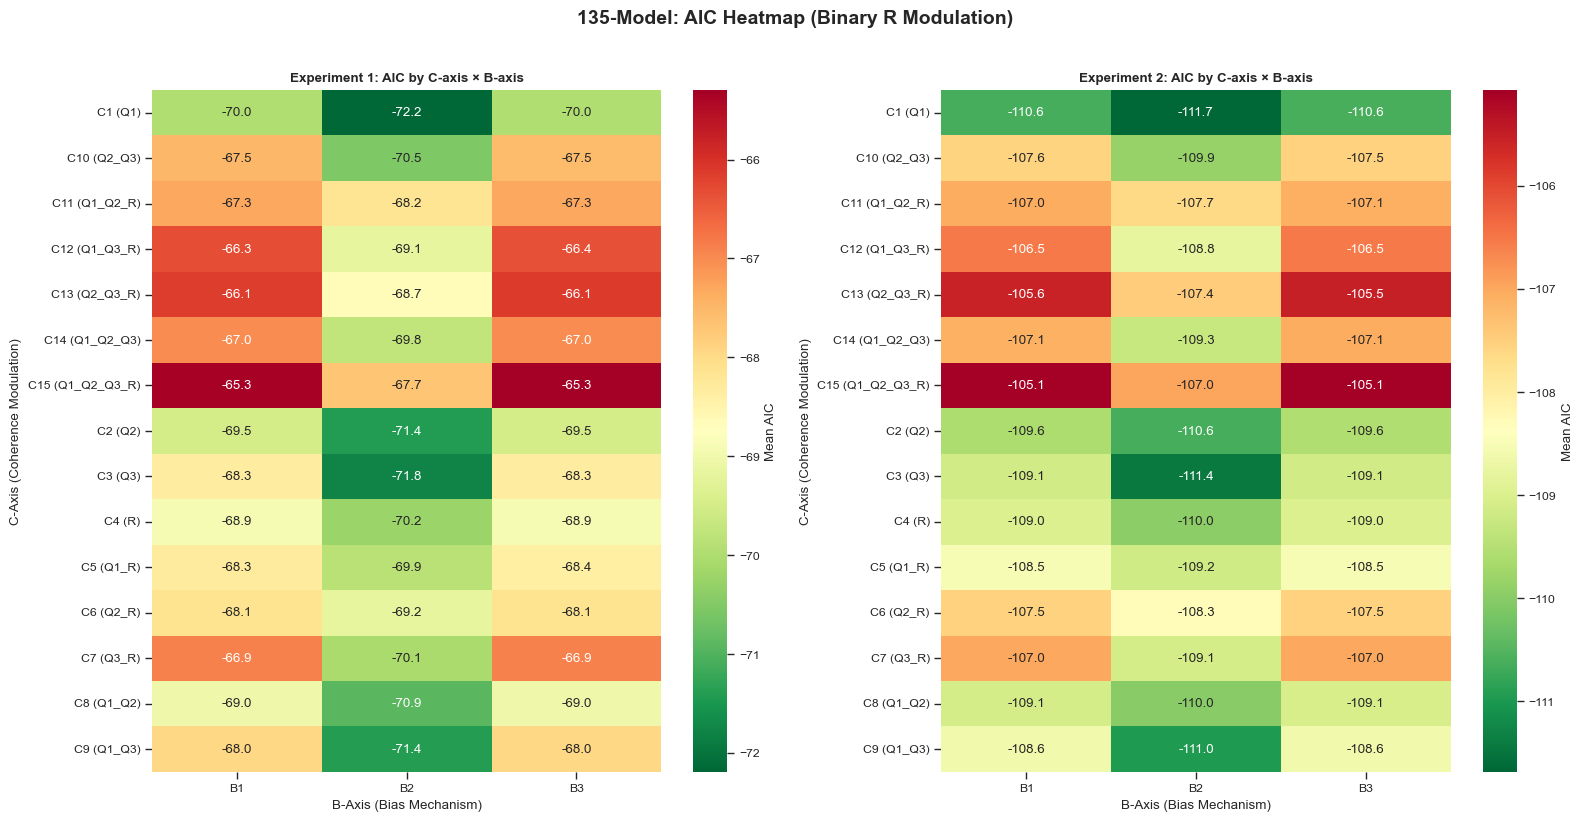

In [12]:
# AIC heatmap by C-axis and B-axis
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        
        exp_data = results_df[results_df['exp'] == exp_num]
        
        # Pivot: C-axis vs B-axis, mean AIC
        pivot = exp_data.groupby(['c_id', 'b_id'])['AIC'].mean().unstack()
        
        # Add C-axis names
        pivot.index = [f"{c} ({C_AXIS[c]['name']})" for c in pivot.index]
        pivot.columns = [B_AXIS[b]['name'] for b in pivot.columns]
        
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                    ax=ax, cbar_kws={'label': 'Mean AIC'})
        ax.set_title(f'Experiment {exp_num}: AIC by C-axis × B-axis', fontweight='bold')
        ax.set_xlabel('B-Axis (Bias Mechanism)')
        ax.set_ylabel('C-Axis (Coherence Modulation)')
    
    plt.suptitle('135-Model: AIC Heatmap (Binary R Modulation)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_path / 'aic_heatmap_c_b.png', dpi=150, bbox_inches='tight')
    plt.show()

### Model Ranking

Horizontal bar chart showing ΔAIC for top 50 models. Colors indicate B-axis (bias mechanism). Vertical lines mark conventional thresholds: ΔAIC = 2 (substantial evidence) and ΔAIC = 10 (strong evidence).

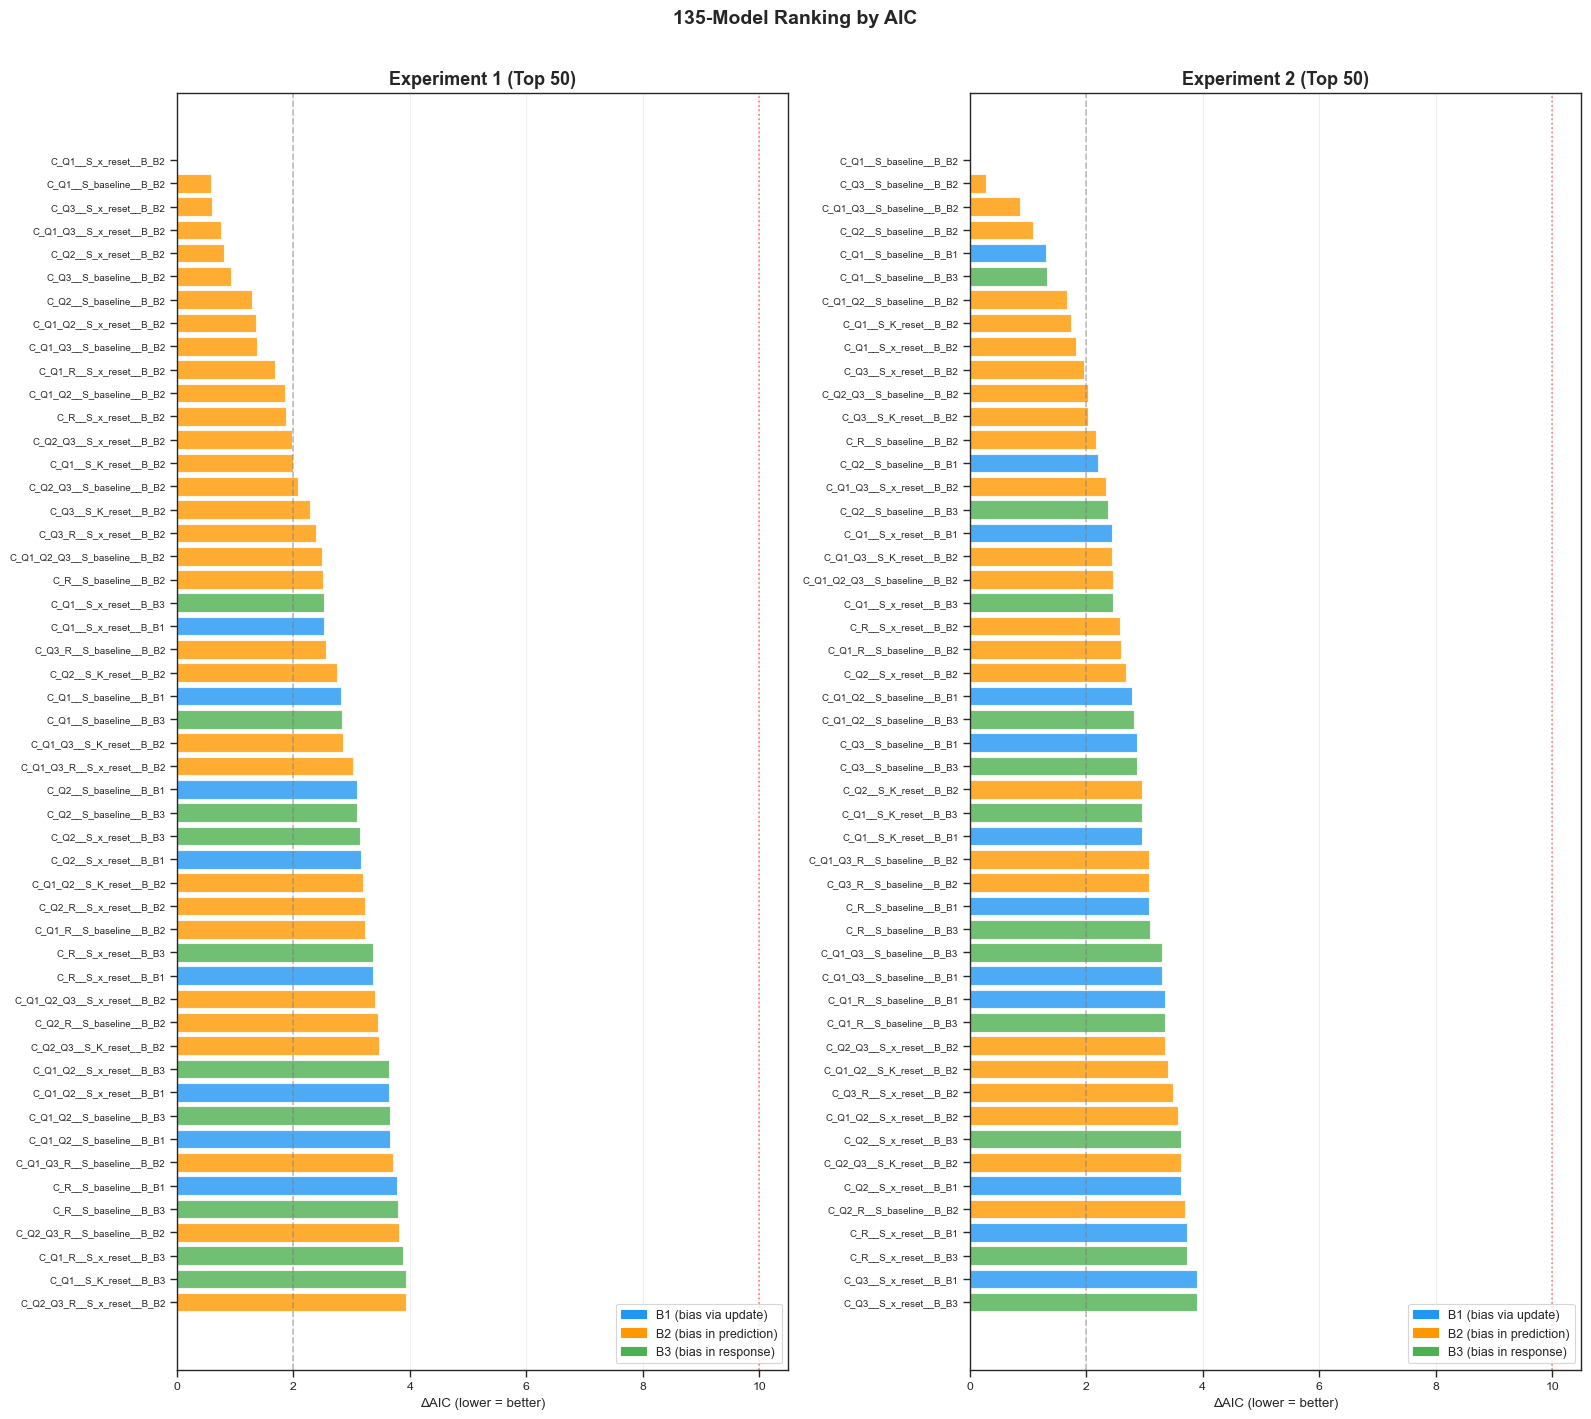

In [13]:
# Delta AIC bar plot
if results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 14))
    
    # Color mapping for B-axis
    b_colors = {'B1': '#2196F3', 'B2': '#FF9800', 'B3': '#4CAF50'}
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        ranking = rank_models(results_df, exp_num=exp_num, criterion='AIC')
        
        # Show top 50 for readability
        top_n = ranking.head(50)
        
        # Colors by B-axis
        colors = [b_colors.get(b, 'gray') for b in top_n['b_id']]
        
        ax.barh(range(len(top_n)), top_n['delta_AIC'], color=colors, alpha=0.8)
        ax.set_yticks(range(len(top_n)))
        ax.set_yticklabels(top_n['model_name'], fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('ΔAIC (lower = better)')
        ax.set_title(f'Experiment {exp_num} (Top 50)', fontsize=13, fontweight='bold')
        ax.axvline(x=2, color='gray', ls='--', alpha=0.5)
        ax.axvline(x=10, color='red', ls=':', alpha=0.5)
        ax.grid(axis='x', alpha=0.3)
        
        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#2196F3', label='B1 (bias via update)'),
            Patch(color='#FF9800', label='B2 (bias in prediction)'),
            Patch(color='#4CAF50', label='B3 (bias in response)'),
        ], loc='lower right', fontsize=9)
    
    plt.suptitle('135-Model Ranking by AIC', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(output_path / 'model_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Posterior Predictive Checks (PPC)

### Central Tendency Index (CTI)
$$\text{CTI} = \text{slope}(r_t \sim s_t)$$

### Serial Dependence Index (SDI)
$$\text{SDI} = \text{slope}(\text{Bias}_t \sim s_{t-1})$$

In [ ]:
# Load saved PPC / trial-level prediction outputs (read-only; no simulation)
CHECK_DIR = root / 'results' / 'kalman_model_checks'
ppc_subject_metrics = pd.read_csv(CHECK_DIR / 'winner_ppc_subject_metrics.csv')
ppc_summary = pd.read_csv(CHECK_DIR / 'winner_ppc_summary.csv')
trial_predictions = pd.read_csv(CHECK_DIR / 'winner_ppc_trial_predictions.csv')
behavioral_effects_subject = pd.read_csv(CHECK_DIR / 'winner_behavioral_effects_subject.csv')
behavioral_effects_summary = pd.read_csv(CHECK_DIR / 'winner_behavioral_effect_summary.csv')

ppc_results = {}
for exp_num in sorted(ppc_subject_metrics['exp'].unique()):
    merged = (ppc_subject_metrics[ppc_subject_metrics['exp'] == exp_num]
              .rename(columns={
                  'cti_obs': 'CTI_obs', 'cti_pred': 'CTI_sim',
                  'sdi_obs': 'SDI_obs', 'sdi_pred': 'SDI_sim',
              })
              .copy())
    summary_row = ppc_summary[ppc_summary['exp'] == exp_num].iloc[0]
    ppc_results[int(exp_num)] = {
        'merged': merged,
        'CTI_r': summary_row['cti_r'],
        'SDI_r': summary_row['sdi_r'],
        'CTI_rec': summary_row['cti_mean_pred'] / summary_row['cti_mean_obs'] * 100,
        'SDI_rec': summary_row['sdi_mean_pred'] / summary_row['sdi_mean_obs'] * 100,
        'model': summary_row['model_name'],
    }

print('Loaded saved PPC subject metrics and trial-level predictions.')
print('No PPC simulation/Kalman filtering is run in this notebook.')
for exp_num, res in ppc_results.items():
    print(f"  Exp {exp_num}: {res['model']} | CTI r={res['CTI_r']:.3f}, SDI r={res['SDI_r']:.3f}")

### PPC results from saved outputs

Subject-level PPC metrics and trial-level predictions are read from `results/kalman_model_checks/`. No new PPC simulation/Kalman filtering is run.


In [ ]:
# Saved PPC summary table
display(ppc_summary)

### PPC Visualization

Scatter plots comparing observed vs. simulated CTI and SDI for each subject. Dashed line = identity; solid line = linear fit.

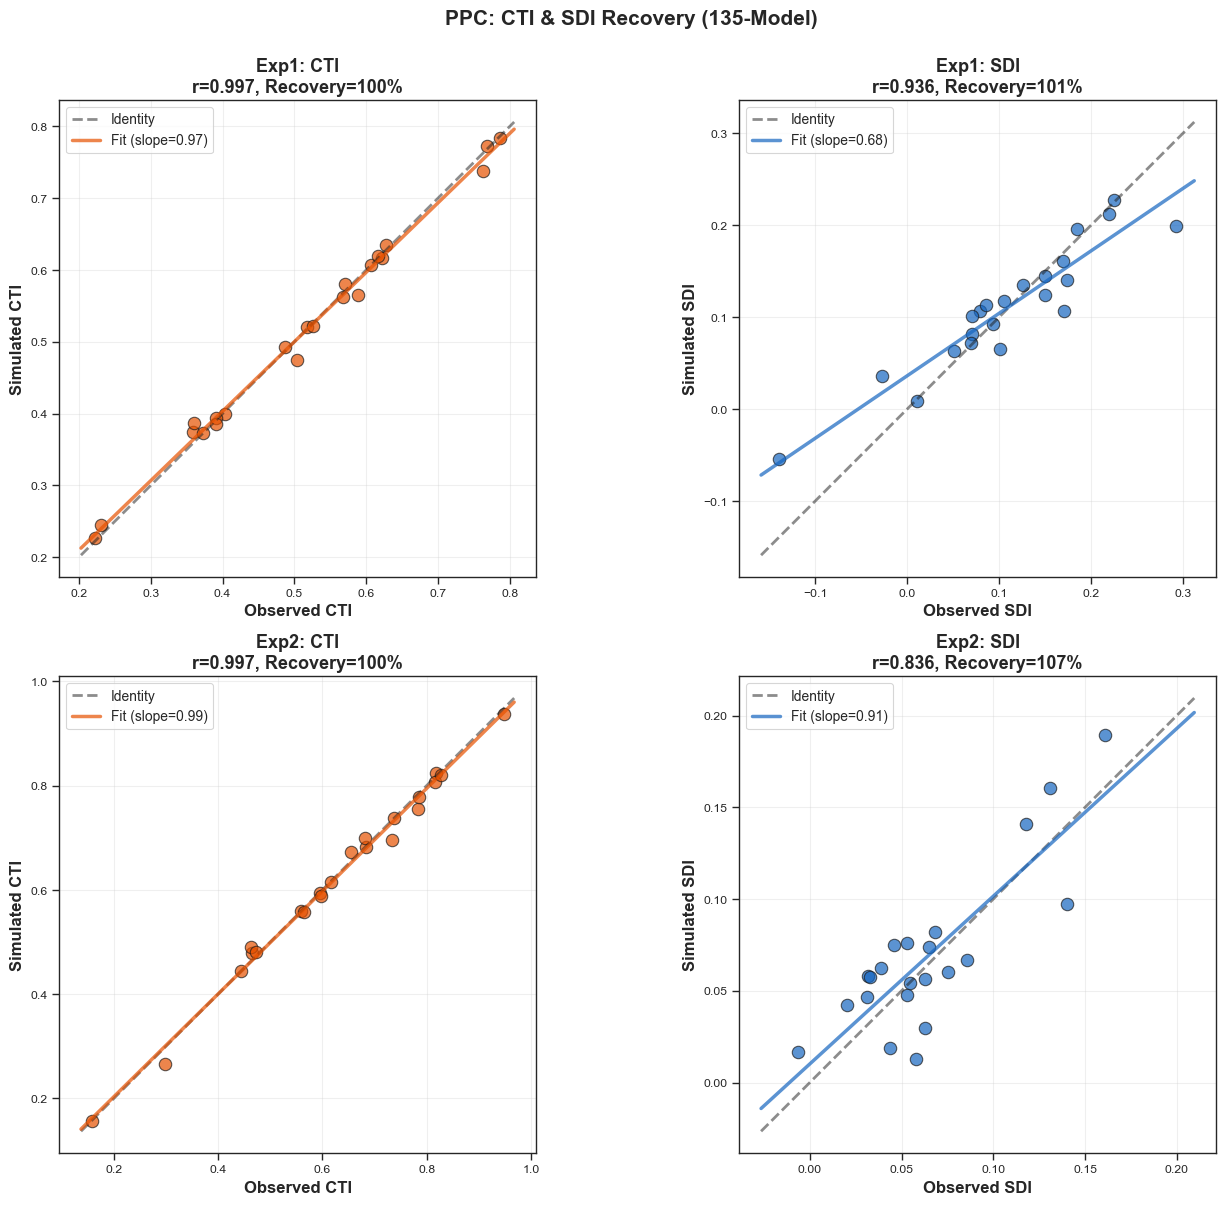

In [16]:
# PPC Scatter Plots (CTI & SDI)
if results_df is not None and ppc_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    for exp_idx, exp in enumerate([1, 2]):
        if exp not in ppc_results:
            continue
        res = ppc_results[exp]
        merged = res['merged']
        
        for metric_idx, (metric, color) in enumerate([('CTI', '#E65100'), ('SDI', '#1565C0')]):
            ax = axes[exp_idx, metric_idx]
            valid = merged.dropna(subset=[f'{metric}_obs', f'{metric}_sim'])
            
            x = valid[f'{metric}_obs']
            y = valid[f'{metric}_sim']
            
            # Scatter
            ax.scatter(x, y, s=80, alpha=0.7, color=color, edgecolors='k', lw=0.8)
            
            # Identity line
            lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5, lw=2, label='Identity')
            
            # Regression line
            if len(valid) > 2:
                slope, intercept = np.polyfit(x, y, 1)
                ax.plot(lims, [slope*l + intercept for l in lims], 
                       color=color, lw=2.5, alpha=0.7, label=f'Fit (slope={slope:.2f})')
            
            ax.set_xlabel(f'Observed {metric}', fontsize=12, fontweight='bold')
            ax.set_ylabel(f'Simulated {metric}', fontsize=12, fontweight='bold')
            ax.set_title(f'Exp{exp}: {metric}\nr={res[f"{metric}_r"]:.3f}, Recovery={res[f"{metric}_rec"]:.0f}%',
                        fontsize=13, fontweight='bold')
            ax.legend(frameon=True, fontsize=10)
            ax.grid(alpha=0.3)
            ax.set_aspect('equal', adjustable='box')
    
    plt.suptitle('PPC: CTI & SDI Recovery (135-Model)', 
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(output_path / 'ppc_cti_sdi_recovery.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠ No PPC results available.')

---
## 7. Summary

In [17]:
if results_df is not None:
    print(f'\nCoherence formula:')
    print(f'  Q(c) = Q_base × exp(α × (1 - c))')
    print(f'  R(c) = 1 if c >= 0.5, r_low if c < 0.5')
    
    for exp_num in [1, 2]:
        best_model, best_data = get_best_model(results_df, exp_num=exp_num)
        mean_aic = best_data['AIC'].mean()
        
        # Parse model name
        c_id = best_data['c_id'].iloc[0]
        s_id = best_data['s_id'].iloc[0]
        b_id = best_data['b_id'].iloc[0]
        
        print(f'\nExperiment {exp_num}:')
        print(f'  Best Model: {best_model}')
        print(f'  C-Axis: {c_id} ({C_AXIS[c_id]["name"]}) - {C_AXIS[c_id]["description"]}')
        print(f'  S-Axis: {s_id} ({S_AXIS[s_id]["name"]}) - {S_AXIS[s_id]["description"]}')
        print(f'  B-Axis: {b_id} ({B_AXIS[b_id]["name"]}) - {B_AXIS[b_id]["description"]}')
        print(f'  Mean AIC: {mean_aic:.2f}')
        print(f'  N params: {best_data["n_params"].iloc[0]}')
        
        # PPC if available
        if exp_num in ppc_results:
            res = ppc_results[exp_num]
            print(f'  PPC CTI: r={res["CTI_r"]:.3f}, Recovery={res["CTI_rec"]:.0f}%')
            print(f'  PPC SDI: r={res["SDI_r"]:.3f}, Recovery={res["SDI_rec"]:.0f}%')
    


Coherence formula:
  Q(c) = Q_base × exp(α × (1 - c))
  R(c) = 1 if c >= 0.5, r_low if c < 0.5

Experiment 1:
  Best Model: C_Q1__S_x_reset__B_B2
  C-Axis: C1 (Q1) - Fast state process noise modulated
  S-Axis: S1 (x_reset) - Switch resets slow state toward prior mean
  B-Axis: B2 (B2) - Bias in prediction via F (F[0,2]=1, response=μ+d0)
  Mean AIC: -73.05
  N params: 9
  PPC CTI: r=0.997, Recovery=100%
  PPC SDI: r=0.936, Recovery=101%

Experiment 2:
  Best Model: C_Q1__S_baseline__B_B2
  C-Axis: C1 (Q1) - Fast state process noise modulated
  S-Axis: S0 (baseline) - No task switching effect
  B-Axis: B2 (B2) - Bias in prediction via F (F[0,2]=1, response=μ+d0)
  Mean AIC: -112.87
  N params: 8
  PPC CTI: r=0.997, Recovery=100%
  PPC SDI: r=0.836, Recovery=107%



### 7.1 Serial Dependence by Condition

Compare observed vs. simulated serial dependence (Bias ~ previous duration) across experimental conditions:
- **Experiment 1**: Repeat vs. Switch (task structure)
- **Experiment 2**: Low vs. High coherence

In [ ]:
# Trial-level serial dependence by condition from saved predictions
def plot_sd_by_condition(data, results_df, exp_num, model_name, ax=None):
    """Plot observed vs saved model-predicted serial dependence by condition.

    Uses results/kalman_model_checks/winner_ppc_trial_predictions.csv.
    Does not generate new simulated responses or run a Kalman filter.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    exp_data = trial_predictions[trial_predictions['exp'] == exp_num].copy()
    if exp_data.empty:
        return ax
    exp_data = exp_data.sort_values(['Sub', 'trial_num'])
    exp_data['preDur'] = exp_data.groupby('Sub')['Duration'].shift(1)

    if exp_num == 1:
        cond_col = 'Structure'
        conds = ['Repeat', 'Switch'] if 'Repeat' in set(exp_data['Structure'].dropna()) else ['Same', 'Switch']
        colors = [COLORS.get('same', '#4C78A8'), COLORS.get('switch', '#F58518')] if isinstance(COLORS, dict) else ['#4C78A8', '#F58518']
        title_suffix = 'Task Structure'
    else:
        exp_data['coh_cat'] = np.where(exp_data['coherence'] < 0.5, 'Low', 'High')
        cond_col = 'coh_cat'
        conds = ['Low', 'High']
        colors = [COLORS.get('low', '#54A24B'), COLORS.get('high', '#E45756')] if isinstance(COLORS, dict) else ['#54A24B', '#E45756']
        title_suffix = 'Coherence'

    for i, cond in enumerate(conds):
        cond_df = exp_data[exp_data[cond_col] == cond].dropna(subset=['preDur', 'obs_bias', 'pred_bias'])
        if cond_df.empty:
            continue
        obs = cond_df.groupby('preDur')['obs_bias'].agg(['mean', 'sem']).reset_index()
        pred = cond_df.groupby('preDur')['pred_bias'].agg(['mean', 'sem']).reset_index()
        color = colors[i % len(colors)]
        ax.errorbar(obs['preDur'], obs['mean'], yerr=obs['sem'], marker='o', lw=2, color=color, label=f'{cond} observed')
        ax.errorbar(pred['preDur'], pred['mean'], yerr=pred['sem'], marker='s', lw=2, ls='--', color=color, alpha=.75, label=f'{cond} saved prediction')
    ax.axhline(0, color='black', lw=.8, alpha=.5)
    ax.set_xlabel('Previous duration')
    ax.set_ylabel('Bias')
    ax.set_title(f'Exp {exp_num}: {title_suffix}')
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
    return ax